<a href="https://colab.research.google.com/github/anteodor/Numerical-Methods/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratory Work: Numerical Methods
**Student:** Anastasiia Teodorovska   
**Language:** Python (Google Colab)




# Task 1. Root-Finding Methods and Stopping Criteria

## 1. Problem Statement

The objective of this task is to study and compare several numerical methods for solving nonlinear equations. The laboratory work focuses on the implementation of iterative root-finding algorithms and the analysis of their convergence behavior under different stopping conditions.

The following numerical methods are considered in the present work: the Bisection method, the Fixed-Point Iteration method, Newton’s method, and the Secant method. Each method is implemented in Python and tested on the same nonlinear function in order to compare their computational behavior, stability, and convergence efficiency.

The computational problem consists in finding numerical approximations of the roots of the nonlinear equation

$$
f(x)=0.
$$

In this laboratory work, the following nonlinear function is analyzed:

$$
f(x)=x\sin(4x).
$$

The obtained approximations are computed iteratively until one of the prescribed stopping criteria is satisfied. Particular attention is given to the influence of approximation accuracy, functional tolerance, and the maximum number of iterations on the convergence of the numerical algorithms.

The laboratory work also includes a graphical analysis of the obtained results together with a comparison of the implemented methods in terms of convergence speed and numerical stability.

## 2. Mathematical Background

Many practical scientific and engineering problems can be reduced to solving nonlinear equations of the form

$$
f(x)=0,
$$

where \(f(x)\) is a nonlinear function. In most cases, such equations cannot be solved analytically, which makes numerical approximation methods essential.

Root-finding methods construct a sequence of approximations that converges to the exact solution of the equation. The efficiency of a numerical method depends on several factors, including convergence speed, numerical stability, sensitivity to the initial approximation, and stopping conditions.

In the present laboratory work, the following nonlinear function is investigated:

$$
f(x)=x\sin(4x).
$$

The derivative required for Newton’s method is

$$
f'(x)=\sin(4x)+4x\cos(4x).
$$

The Bisection method is based on the Intermediate Value Theorem. If a continuous function changes sign on an interval \([a,b]\), then at least one root exists inside the interval. The method repeatedly halves the interval and selects the subinterval in which the sign change is preserved. The midpoint of the interval is computed as

$$
c=\frac{a+b}{2}.
$$

The method is guaranteed to converge for continuous functions satisfying the sign-change condition, although its convergence rate is relatively slow.

The Fixed-Point Iteration method transforms the original equation into the equivalent form

$$
x=\varphi(x),
$$

after which successive approximations are generated using the iterative relation

$$
x_{n+1}=\varphi(x_n).
$$

The convergence of the method depends strongly on the properties of the transformation function

$$
\varphi(x)
$$

and on the choice of the initial approximation.

Newton’s method is one of the most widely used root-finding algorithms due to its rapid convergence near the solution. The method is derived from the tangent line approximation of the function and generates successive approximations according to the formula

$$
x_{n+1}=x_n-\frac{f(x_n)}{f'(x_n)}.
$$

When the initial approximation is sufficiently close to the exact root and the derivative is nonzero, Newton’s method demonstrates quadratic convergence.

The Secant method is closely related to Newton’s method but avoids the direct computation of derivatives. Instead, the derivative is approximated numerically using two previous approximations. The iterative formula of the Secant method is

$$
x_{n+1}=x_n-f(x_n)\frac{x_n-x_{n-1}}{f(x_n)-f(x_{n-1})}.
$$

Compared to Newton’s method, the Secant method generally converges more slowly but requires less analytical information about the function.

Since all considered algorithms are iterative, appropriate stopping criteria must be introduced in order to terminate the computational process. In this laboratory work, three stopping conditions are analyzed.

The first criterion limits the maximum number of iterations:

$$
n \geq N_{\max}.
$$

The second criterion is based on the difference between two successive approximations:

$$
|x_n-x_{n-1}| \leq \varepsilon.
$$

The third criterion is based on the value of the function at the current approximation:

$$
|f(x_n)| \leq \varepsilon.
$$

These stopping criteria allow the iterative process to terminate once the required approximation accuracy has been achieved.

## 3. Program Implementation

The program was implemented in Python using the Google Colab environment. The implementation was organized into several logical components in order to improve readability, maintainability, and clarity of the numerical experiments.

At the beginning of the program, the required scientific libraries were imported. The NumPy library was used for numerical computations, pandas was used for tabular representation of the iteration results, and Matplotlib was applied for graphical visualization of the convergence behavior of the implemented methods.

A separate function was defined for the nonlinear equation

$$
f(x)=x\sin(4x),
$$

together with its analytical derivative

$$
f'(x)=\sin(4x)+4x\cos(4x),
$$

which is required for Newton’s method.

The implementation also includes a transformation function used in the Fixed-Point Iteration method. This transformation generates successive approximations according to the fixed-point iterative scheme.

To ensure consistent convergence analysis, global parameters were introduced for the stopping criteria, including the approximation tolerance, functional tolerance, and the maximum allowed number of iterations. A small auxiliary constant was additionally used to avoid numerical instability caused by division by values close to zero.

A separate helper function was implemented for checking the stopping conditions during the iterative process. This function verifies whether the required approximation accuracy has been achieved, whether the functional value is sufficiently small, or whether the maximum number of iterations has been reached.

Each numerical method was implemented as an independent Python function. The Bisection method performs interval halving while preserving the sign-change condition. The Fixed-Point Iteration method repeatedly applies the transformation function to generate new approximations. Newton’s method uses the tangent line approximation together with the analytical derivative of the function, while the Secant method approximates the derivative numerically using two previous approximations.

For every iteration, the program stores the iteration number, the current approximation, the approximation error, and the value of the function. The full iteration history is preserved for further analysis and visualization.

To compare the implemented methods under identical conditions, the program executes all algorithms using predefined initial approximations or intervals. The obtained numerical results are collected into pandas DataFrames, which provide a convenient and structured representation of the computational experiments.

Several visualization procedures were additionally implemented. The program plots the investigated nonlinear function, displays the roots obtained by different numerical methods, and illustrates the dependence of the convergence behavior on the initial approximation. Additional graphical analysis was performed for Newton’s method in order to visualize the tangent-line interpretation of the algorithm and investigate the dependence of convergence on the starting point.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define the function and its derivative

def f(x):

    # Function for root finding: f(x) = x * sin(4x)
    return x * np.sin(4 * x)


def df(x):

    # Analytical derivative: f'(x) = sin(4x) + 4x cos(4x)
    return np.sin(4 * x) + 4 * x * np.cos(4 * x)


def phi(x, alpha=0.1):

    # Transformation for fixed-point iteration: x = phi(x)
    # The parameter alpha is chosen small enough to support convergence.
    return x - alpha * f(x)

In [3]:
# General parameters for stopping criteria

TOL_X = 1e-6      # tolerance for approximation accuracy
TOL_F = 1e-6      # tolerance for functional value
MAX_ITER = 100    # maximum number of iterations
EPS = 1e-12       # small value to avoid division by zero

In [4]:
# Helper function for checking stopping criteria

def check_stopping_criteria(iteration, x_new, x_old=None):

    if iteration >= MAX_ITER:
        return True, "Maximum number of iterations reached"

    if x_old is not None and abs(x_new - x_old) <= TOL_X:
        return True, "Approximation accuracy reached"

    if abs(f(x_new)) <= TOL_F:
        return True, "Functional value tolerance reached"

    return False, None

In [5]:
# 1. Bisection Method

def bisection_method(a, b):

    if f(a) * f(b) > 0:
        return None, 0, "Invalid interval: f(a) and f(b) have the same sign", []

    history = []

    for iteration in range(1, MAX_ITER + 1):
        c = (a + b) / 2
        error = abs(b - a) / 2

        history.append({
            "iteration": iteration,
            "x_n": c,
            "|e_n|": error,
            "|f(x_n)|": abs(f(c))
        })

        stop, reason = check_stopping_criteria(iteration, c, None)

        if error <= TOL_X:
            return c, iteration, "Bisection interval accuracy reached", history

        if stop:
            return c, iteration, reason, history

        if f(a) * f(c) < 0:
            b = c
        else:
            a = c

    return c, MAX_ITER, "Maximum number of iterations reached", history

In [6]:
# 2. Fixed-Point Iteration Method

def fixed_point_iteration(x0):

    history = []
    x_old = x0

    for iteration in range(1, MAX_ITER + 1):
        x_new = phi(x_old)

        history.append({
            "iteration": iteration,
            "x_n": x_new,
            "|x_n - x_(n-1)|": abs(x_new - x_old),
            "|f(x_n)|": abs(f(x_new))
        })

        stop, reason = check_stopping_criteria(iteration, x_new, x_old)

        if stop:
            return x_new, iteration, reason, history

        x_old = x_new

    return x_new, MAX_ITER, "Maximum number of iterations reached", history

In [7]:
# 3. Newton's Method

def newton_method(x0):

    history = []
    x_old = x0

    for iteration in range(1, MAX_ITER + 1):
        derivative = df(x_old)

        if abs(derivative) < EPS:
            return None, iteration, "Derivative is zero or too close to zero", history

        x_new = x_old - f(x_old) / derivative

        history.append({
            "iteration": iteration,
            "x_n": x_new,
            "|x_n - x_(n-1)|": abs(x_new - x_old),
            "|f(x_n)|": abs(f(x_new))
        })

        stop, reason = check_stopping_criteria(iteration, x_new, x_old)

        if stop:
            return x_new, iteration, reason, history

        x_old = x_new

    return x_new, MAX_ITER, "Maximum number of iterations reached", history

In [8]:
# 4. Secant Method

def secant_method(x0, x1):

    history = []

    for iteration in range(1, MAX_ITER + 1):
        denominator = f(x1) - f(x0)

        if abs(denominator) < EPS:
            return None, iteration, "Division by zero or too small denominator", history

        x_new = x1 - f(x1) * (x1 - x0) / denominator

        history.append({
            "iteration": iteration,
            "x_n": x_new,
            "|x_n - x_(n-1)|": abs(x_new - x1),
            "|f(x_n)|": abs(f(x_new))
        })

        stop, reason = check_stopping_criteria(iteration, x_new, x1)

        if stop:
            return x_new, iteration, reason, history

        x0, x1 = x1, x_new

    return x_new, MAX_ITER, "Maximum number of iterations reached", history

In [9]:
# Compare all methods for selected starting values

results = []

# Bisection method intervals
bisection_intervals = [
    (-2.0, -1.5),
    (-1.0, -0.5),
    (-0.2, 0.2),
    (0.5, 1.0),
    (1.0, 1.5)
]

for a, b in bisection_intervals:
    root, iterations, reason, history = bisection_method(a, b)

    results.append({
        "Method": "Bisection",
        "Initial data": f"[{a}, {b}]",
        "Root found": root,
        "Iterations": iterations,
        "Stopping criterion": reason
    })


# Initial guesses for iterative methods
initial_guesses = [-2.0, -1.5, -1.0, -0.5, 0.2, 0.5, 1.0, 1.5, 2.0]

for x0 in initial_guesses:
    root, iterations, reason, history = fixed_point_iteration(x0)

    results.append({
        "Method": "Fixed-point iteration",
        "Initial data": f"x0 = {x0}",
        "Root found": root,
        "Iterations": iterations,
        "Stopping criterion": reason
    })


for x0 in initial_guesses:
    root, iterations, reason, history = newton_method(x0)

    results.append({
        "Method": "Newton",
        "Initial data": f"x0 = {x0}",
        "Root found": root,
        "Iterations": iterations,
        "Stopping criterion": reason
    })


# Initial pairs for secant method
secant_pairs = [
    (-2.0, -1.8),
    (-1.5, -1.2),
    (-0.7, -0.4),
    (0.2, 0.4),
    (0.8, 1.1),
    (1.5, 1.8)
]

for x0, x1 in secant_pairs:
    root, iterations, reason, history = secant_method(x0, x1)

    results.append({
        "Method": "Secant",
        "Initial data": f"x0 = {x0}, x1 = {x1}",
        "Root found": root,
        "Iterations": iterations,
        "Stopping criterion": reason
    })


results_df = pd.DataFrame(results)
results_df

,Method,Initial data,Root found,Iterations,Stopping criterion
0,Bisection,"[-2.0, -1.5]",-1.570796,19,Bisection interval accuracy reached
1,Bisection,"[-1.0, -0.5]",-0.785398,19,Bisection interval accuracy reached
2,Bisection,"[-0.2, 0.2]",NaN,0,Invalid interval: f(a) and f(b) have the same ...
3,Bisection,"[0.5, 1.0]",0.785398,19,Bisection interval accuracy reached
4,Bisection,"[1.0, 1.5]",NaN,0,Invalid interval: f(a) and f(b) have the same ...
5,Fixed-point iteration,x0 = -2.0,-2.356194,7,Approximation accuracy reached
6,Fixed-point iteration,x0 = -1.5,-0.785400,36,Approximation accuracy reached
7,Fixed-point iteration,x0 = -1.0,-0.785400,30,Approximation accuracy reached
8,Fixed-point iteration,x0 = -0.5,-0.785396,34,Approximation accuracy reached
9,Fixed-point iteration,x0 = 0.2,0.022034,100,Maximum number of iterations reached


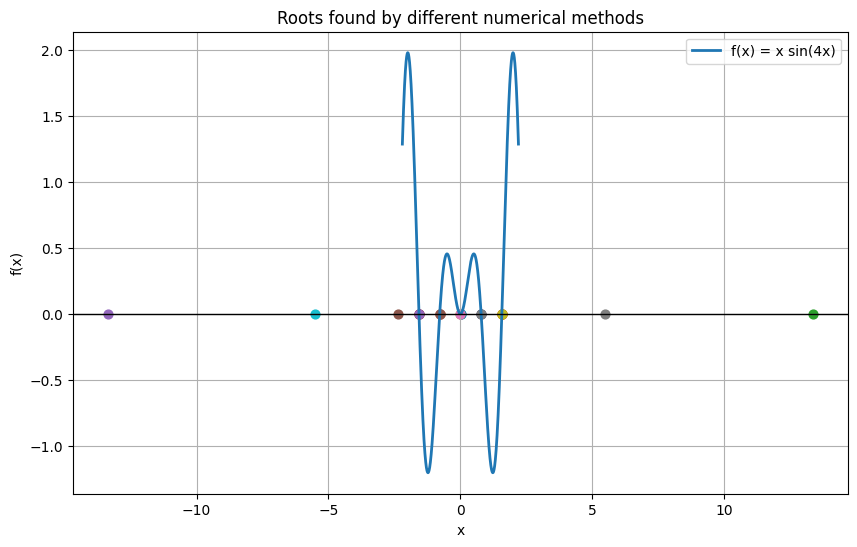

In [10]:
# Plot the function and all roots found

x_values = np.linspace(-2.2, 2.2, 1000)
y_values = f(x_values)

plt.figure(figsize=(10, 6))

plt.plot(x_values, y_values, label="f(x) = x sin(4x)", linewidth=2)
plt.axhline(0, color="black", linewidth=1)

for _, row in results_df.iterrows():
    if row["Root found"] is not None:
        plt.scatter(row["Root found"], f(row["Root found"]), s=40)

plt.title("Roots found by different numerical methods")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

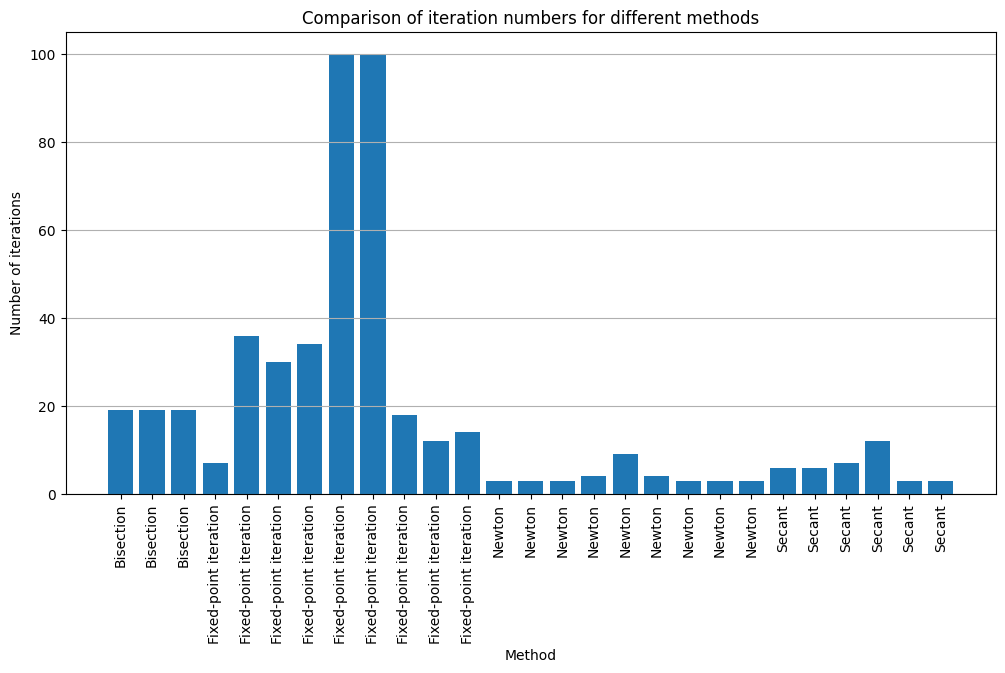

In [11]:
# Compare number of iterations for all successful runs

successful_results = results_df[results_df["Root found"].notnull()].copy()

plt.figure(figsize=(12, 6))

plt.bar(
    range(len(successful_results)),
    successful_results["Iterations"]
)

plt.xticks(
    range(len(successful_results)),
    successful_results["Method"],
    rotation=90
)

plt.title("Comparison of iteration numbers for different methods")
plt.xlabel("Method")
plt.ylabel("Number of iterations")
plt.grid(axis="y")
plt.show()

In [12]:
# Detailed iteration history example

root, iterations, reason, history = newton_method(1.5)

history_df = pd.DataFrame(history)

print("Detailed Newton method example")
print(f"Initial guess: x0 = 1.5")
print(f"Root found: {root}")
print(f"Number of iterations: {iterations}")
print(f"Stopping criterion: {reason}")

history_df

Detailed Newton method example
Initial guess: x0 = 1.5
Root found: 1.570796327032285
Number of iterations: 3
Stopping criterion: Functional value tolerance reached


,iteration,x_n,|x_n - x_(n-1)|,|f(x_n)|
0,1,1.576460,0.076460,3.571074e-02
1,2,1.570816,0.005644,1.213432e-04
2,3,1.570796,0.000019,1.491554e-09


## 4. Results and Discussion

The implemented numerical methods were tested on the nonlinear function

$$
f(x)=x\sin(4x).
$$

The obtained computational results demonstrate that all implemented methods were capable of approximating roots of the equation under appropriate initial conditions. However, the convergence behavior and computational efficiency differed significantly between the methods.

The Bisection method demonstrated stable and predictable convergence whenever the initial interval satisfied the sign-change condition. The method consistently converged to the expected roots, although the number of iterations was relatively high compared to the other methods. This behavior is expected due to the linear convergence rate of the algorithm. In cases where the selected interval did not contain a sign change, the method correctly identified the interval as invalid and terminated the computation.

The Fixed-Point Iteration method showed slower convergence and stronger sensitivity to the choice of the initial approximation. For several initial guesses, the method required a large number of iterations before satisfying the stopping criterion. In some cases, the algorithm reached the maximum allowed number of iterations without achieving convergence, which indicates that the selected transformation function did not guarantee stable convergence for all starting points.

Newton’s method demonstrated the fastest convergence among all implemented algorithms. For most initial approximations, the method converged within only a few iterations. This behavior confirms the quadratic convergence property of Newton’s method when the initial approximation is sufficiently close to the root and the derivative remains well-defined. However, the obtained results also illustrate the sensitivity of Newton’s method to the initial guess. Depending on the starting point, the method converged to different roots of the nonlinear function.

The Secant method also demonstrated efficient convergence behavior. Although it generally required slightly more iterations than Newton’s method, it successfully approximated the roots without requiring analytical computation of the derivative. The method provided a good balance between computational efficiency and implementation simplicity.

The graphical analysis illustrates the distribution of the roots obtained by different numerical methods. The plots additionally show that the nonlinear function possesses multiple roots and that different initial approximations may lead iterative algorithms to different solutions.

The comparison of iteration numbers clearly indicates that Newton’s method and the Secant method converged substantially faster than the Bisection method and the Fixed-Point Iteration method. The Fixed-Point Iteration method exhibited the slowest convergence and the highest sensitivity to the selection of the initial approximation.

The detailed iteration history generated for Newton’s method illustrates the rapid decrease of both the approximation error and the functional value during the iterative process. The results confirm the high computational efficiency of tangent-based root-finding algorithms for nonlinear equations.

## 5. Conclusions

In this laboratory work, several numerical methods for solving nonlinear equations were implemented and analyzed using Python in the Google Colab environment. The Bisection method, Fixed-Point Iteration method, Newton’s method, and Secant method were successfully applied to the nonlinear equation

$$
f(x)=x\sin(4x).
$$

The implemented algorithms were tested using multiple initial approximations and intervals in order to investigate their convergence behavior and computational efficiency. Three stopping criteria were incorporated into the implementation, including the maximum number of iterations, approximation accuracy, and functional value tolerance.

The obtained results demonstrated that all considered methods are capable of approximating roots of nonlinear equations under appropriate conditions. The Bisection method provided stable and guaranteed convergence but required a relatively large number of iterations. The Fixed-Point Iteration method showed slower convergence and significant dependence on the transformation function and initial approximation.

Newton’s method demonstrated the fastest convergence and required only a small number of iterations in most computational experiments. However, the method also showed sensitivity to the choice of the initial guess. The Secant method achieved efficient convergence without requiring explicit computation of derivatives and provided a practical alternative to Newton’s method.

The graphical analysis confirmed that the investigated nonlinear function possesses multiple roots and that different initial approximations may lead iterative methods to different solutions. The numerical experiments additionally illustrated the importance of properly selected stopping criteria for ensuring both computational efficiency and numerical accuracy.

Overall, the laboratory work provided practical experience in the implementation and analysis of iterative numerical methods for solving nonlinear equations and demonstrated the advantages and limitations of different root-finding algorithms.

# Task 2. Analysis of Newton’s Method for Different Initial Guesses

## 1. Problem Statement

The objective of this task is to investigate the convergence behavior of Newton’s method for different initial approximations when solving a nonlinear equation.

Particular attention is given to the dependence of the obtained root and the number of iterations on the choice of the starting point. Since nonlinear functions may possess multiple roots, different initial approximations can lead the iterative process to different solutions. For this reason, the sensitivity of Newton’s method to the initial guess represents an important aspect of numerical analysis.

The computational experiments are performed for the nonlinear function

$$
f(x)=x\sin(4x).
$$

Newton’s method is applied repeatedly for a wide range of initial approximations distributed over a selected interval. For each initial guess, the method computes the approximated root, records the number of iterations required for convergence, and stores the stopping condition that terminates the iterative process.

The laboratory work also includes graphical analysis of the obtained numerical results. Special attention is given to the visualization of the dependence between the initial approximation and the corresponding root, as well as to the analysis of the convergence speed of the method.

Additionally, the geometric interpretation of Newton’s method based on tangent-line approximation is illustrated in order to demonstrate the mechanism of iterative convergence.

## 2. Mathematical Background

Newton’s method is one of the most important iterative techniques for solving nonlinear equations. The method is based on the local linear approximation of a nonlinear function using its tangent line.

For a nonlinear equation of the form

$$
f(x)=0,
$$

Newton’s method generates a sequence of successive approximations according to the iterative formula

$$
x_{n+1}=x_n-\frac{f(x_n)}{f'(x_n)},
$$

where \(x_n\) is the current approximation and \(f'(x_n)\) is the derivative of the function evaluated at the same point.

Geometrically, the method constructs the tangent line to the graph of the function at the point \((x_n,f(x_n))\). The intersection of this tangent line with the \(x\)-axis becomes the next approximation \(x_{n+1}\). Repeating this process generates a sequence that may converge to a root of the nonlinear equation.

In the present laboratory work, Newton’s method is applied to the nonlinear function

$$
f(x)=x\sin(4x),
$$

whose derivative is

$$
f'(x)=\sin(4x)+4x\cos(4x).
$$

Since the investigated function possesses multiple roots, the convergence behavior of Newton’s method depends strongly on the selected initial approximation. Different starting points may lead the iterative process to different roots, even when the initial guesses are relatively close to each other.

One of the main advantages of Newton’s method is its rapid convergence. When the initial approximation is sufficiently close to the exact root and the derivative remains nonzero, the method demonstrates quadratic convergence, meaning that the approximation error decreases very rapidly during the iterative process.

At the same time, Newton’s method may become unstable when the derivative is close to zero or when the initial approximation is selected poorly. In such cases, the method may converge slowly, diverge, or converge to an unexpected root.

To terminate the iterative process, stopping criteria are introduced. In the present work, the stopping conditions are based on the approximation accuracy, the functional value tolerance, and the maximum number of iterations. These criteria ensure both numerical stability and sufficient computational accuracy during the convergence process.

## 4. Program Implementation

The program was implemented in Python using the Google Colab environment. The implementation was designed specifically for the analysis of Newton’s method under different initial approximations.

At the beginning of the program, the required scientific libraries were imported. NumPy was used for numerical computations, pandas was applied for storing and organizing the computational results, and Matplotlib was used for graphical visualization of the convergence behavior.

Separate functions were defined for the nonlinear equation

$$
f(x)=x\sin(4x)
$$

and for its analytical derivative

$$
f'(x)=\sin(4x)+4x\cos(4x).
$$

The core part of the implementation consists of a dedicated Newton-method function. This function performs the iterative computation of successive approximations using the tangent-line formula and stores the complete iteration history during the convergence process.

To ensure numerical stability, the implementation additionally verifies whether the derivative is sufficiently far from zero before performing the division step of Newton’s iteration. This prevents numerical instability and divergence caused by undefined or excessively large approximation steps.

Global parameters were introduced for the stopping criteria, including the approximation tolerance, functional tolerance, and maximum number of iterations. These parameters were applied consistently throughout all computational experiments.

The implementation was then extended by introducing an automated loop over a large set of initial approximations. Newton’s method was repeatedly executed for starting points distributed uniformly over the investigated interval. For every initial guess, the program recorded the obtained root, the number of iterations required for convergence, and the stopping condition that terminated the iterative process.

The obtained numerical results were collected into pandas DataFrames in order to simplify subsequent analysis and visualization. Additional processing was performed to group approximately identical roots and investigate how different initial approximations influence the convergence behavior of the method.

Several graphical visualization procedures were implemented as part of the analysis. The program plots the investigated nonlinear function, visualizes the roots obtained for different starting points, and illustrates the dependence between the initial approximation and the convergence speed of Newton’s method.

An additional visualization was constructed to demonstrate the geometric interpretation of Newton’s method. The graph illustrates the tangent line at the selected initial approximation together with the first Newton step, providing a graphical explanation of how the iterative process approaches the root of the nonlinear equation.

In [13]:
# Run Newton's method for different initial guesses

newton_results = []

# A dense set of initial guesses on the interval [-2, 2]
initial_guesses = np.linspace(-2, 2, 41)

for x0 in initial_guesses:
    root, iterations, reason, history = newton_method(x0)

    newton_results.append({
        "Initial guess": x0,
        "Root found": root,
        "Iterations": iterations,
        "Stopping criterion": reason
    })

newton_results_df = pd.DataFrame(newton_results)

newton_results_df

,Initial guess,Root found,Iterations,Stopping criterion
0,-2.0,-13.351769,3,Functional value tolerance reached
1,-1.9,-3.141593,5,Functional value tolerance reached
2,-1.8,-1.570796,4,Functional value tolerance reached
3,-1.7,-1.570796,3,Functional value tolerance reached
4,-1.6,-1.570796,2,Functional value tolerance reached
5,-1.5,-1.570796,3,Functional value tolerance reached
6,-1.4,-1.570796,4,Approximation accuracy reached
7,-1.3,-3.141593,6,Approximation accuracy reached
8,-1.2,0.785398,4,Functional value tolerance reached
9,-1.1,-0.785398,5,Functional value tolerance reached


In [14]:
# Round roots to group approximately equal roots

newton_results_df["Rounded root"] = newton_results_df["Root found"].round(6)

newton_results_df

,Initial guess,Root found,Iterations,Stopping criterion,Rounded root
0,-2.0,-13.351769,3,Functional value tolerance reached,-13.351769
1,-1.9,-3.141593,5,Functional value tolerance reached,-3.141593
2,-1.8,-1.570796,4,Functional value tolerance reached,-1.570796
3,-1.7,-1.570796,3,Functional value tolerance reached,-1.570796
4,-1.6,-1.570796,2,Functional value tolerance reached,-1.570796
5,-1.5,-1.570796,3,Functional value tolerance reached,-1.570796
6,-1.4,-1.570796,4,Approximation accuracy reached,-1.570796
7,-1.3,-3.141593,6,Approximation accuracy reached,-3.141593
8,-1.2,0.785398,4,Functional value tolerance reached,0.785398
9,-1.1,-0.785398,5,Functional value tolerance reached,-0.785398


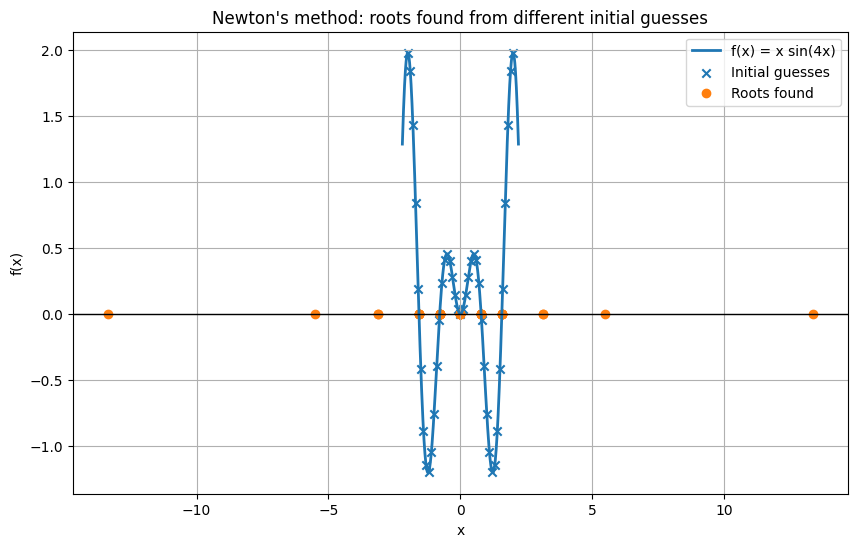

In [15]:
# Plot the function and roots found by Newton's method

x_values = np.linspace(-2.2, 2.2, 1000)
y_values = f(x_values)

plt.figure(figsize=(10, 6))

plt.plot(x_values, y_values, label="f(x) = x sin(4x)", linewidth=2)
plt.axhline(0, color="black", linewidth=1)

# Plot initial guesses
plt.scatter(
    newton_results_df["Initial guess"],
    f(newton_results_df["Initial guess"]),
    marker="x",
    label="Initial guesses"
)

# Plot found roots
successful_newton = newton_results_df[newton_results_df["Root found"].notnull()]

plt.scatter(
    successful_newton["Root found"],
    f(successful_newton["Root found"]),
    marker="o",
    label="Roots found"
)

plt.title("Newton's method: roots found from different initial guesses")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

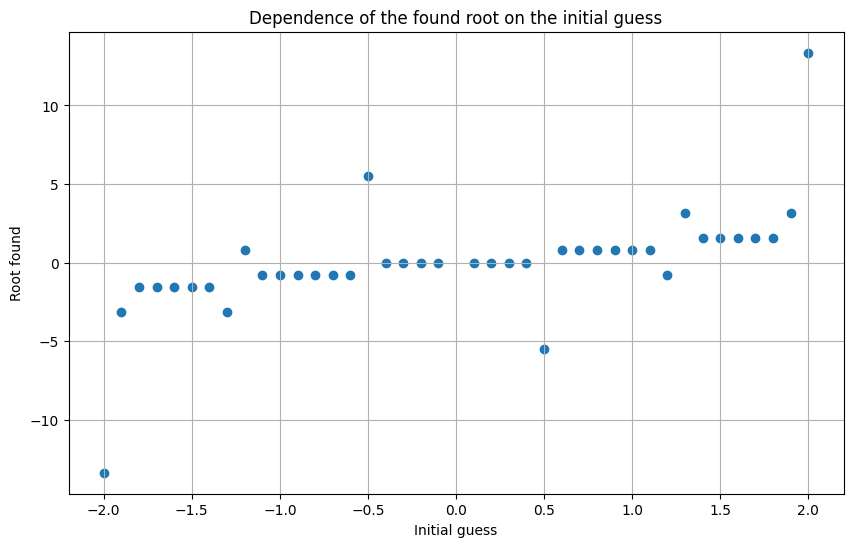

In [16]:
# Analyze how the initial guess affects the found root

plt.figure(figsize=(10, 6))

plt.scatter(
    successful_newton["Initial guess"],
    successful_newton["Root found"]
)

plt.title("Dependence of the found root on the initial guess")
plt.xlabel("Initial guess")
plt.ylabel("Root found")
plt.grid(True)
plt.show()

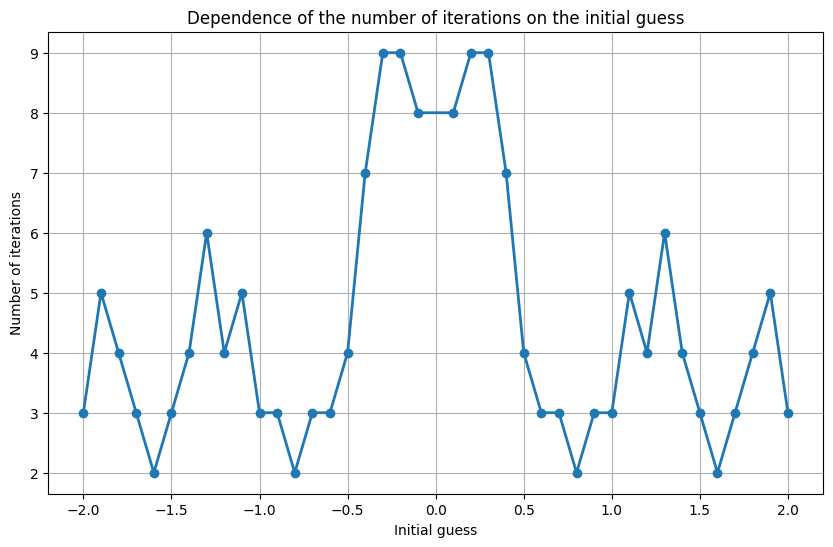

In [17]:
# Analyze how the initial guess affects the number of iterations

plt.figure(figsize=(10, 6))

plt.plot(
    successful_newton["Initial guess"],
    successful_newton["Iterations"],
    marker="o",
    linewidth=2
)

plt.title("Dependence of the number of iterations on the initial guess")
plt.xlabel("Initial guess")
plt.ylabel("Number of iterations")
plt.grid(True)
plt.show()

In [18]:
# Summary table by detected roots

root_summary = (
    successful_newton
    .groupby("Rounded root")
    .agg(
        Number_of_initial_guesses=("Initial guess", "count"),
        Min_iterations=("Iterations", "min"),
        Max_iterations=("Iterations", "max"),
        Mean_iterations=("Iterations", "mean")
    )
    .reset_index()
)

root_summary

,Rounded root,Number_of_initial_guesses,Min_iterations,Max_iterations,Mean_iterations
0,-13.351769,1,3,3,3.000000
1,-5.497787,1,4,4,4.000000
2,-3.141593,2,5,6,5.500000
3,-1.570796,5,2,4,3.200000
4,-0.785398,7,2,5,3.285714
5,-0.000377,1,8,8,8.000000
6,-0.000361,1,9,9,9.000000
7,-0.000332,1,9,9,9.000000
8,-0.000306,1,7,7,7.000000
9,0.000306,1,7,7,7.000000


In [19]:
# Display the most difficult initial guesses

difficult_cases = (
    successful_newton
    .sort_values(by="Iterations", ascending=False)
    .head(10)
)

difficult_cases

,Initial guess,Root found,Iterations,Stopping criterion,Rounded root
17,-0.3,-0.000361,9,Functional value tolerance reached,-0.000361
18,-0.2,-0.000332,9,Functional value tolerance reached,-0.000332
23,0.3,0.000361,9,Functional value tolerance reached,0.000361
22,0.2,0.000332,9,Functional value tolerance reached,0.000332
21,0.1,0.000377,8,Functional value tolerance reached,0.000377
19,-0.1,-0.000377,8,Functional value tolerance reached,-0.000377
16,-0.4,0.000306,7,Functional value tolerance reached,0.000306
24,0.4,-0.000306,7,Functional value tolerance reached,-0.000306
33,1.3,3.141593,6,Approximation accuracy reached,3.141593
7,-1.3,-3.141593,6,Approximation accuracy reached,-3.141593


In [20]:
# Detailed Newton iteration history for selected initial guesses

selected_initial_guesses = [-1.8, -1.0, -0.2, 0.2, 1.0, 1.8]

for x0 in selected_initial_guesses:
    root, iterations, reason, history = newton_method(x0)

    print("=" * 70)
    print(f"Initial guess: {x0}")
    print(f"Root found: {root}")
    print(f"Number of iterations: {iterations}")
    print(f"Stopping criterion: {reason}")
    print("=" * 70)

    display(pd.DataFrame(history))

Initial guess: -1.8
Root found: -1.5707963267995833
Number of iterations: 4
Stopping criterion: Functional value tolerance reached


,iteration,x_n,|x_n - x_(n-1)|,|f(x_n)|
0,1,-1.523877,0.276123,2.843186e-01
1,2,-1.572882,0.049004,1.312086e-02
2,3,-1.570799,0.002083,1.704812e-05
3,4,-1.570796,0.000003,2.944699e-11


Initial guess: -1.0
Root found: -0.785398185794586
Number of iterations: 3
Stopping criterion: Functional value tolerance reached


,iteration,x_n,|x_n - x_(n-1)|,|f(x_n)|
0,1,-0.775521,0.224479,3.063106e-02
1,2,-0.785531,0.010010,4.169255e-04
2,3,-0.785398,0.000133,7.036269e-08


Initial guess: -0.2
Root found: -0.00033224423771066917
Number of iterations: 9
Stopping criterion: Functional value tolerance reached


...

,iteration,x_n,|x_n - x_(n-1)|,|f(x_n)|
0,1,0.087449,0.112551,2.996929e-02
1,2,0.042807,0.044642,7.293851e-03
2,3,0.021298,0.021509,1.812223e-03
3,4,0.010636,0.010662,4.523691e-04
4,5,0.005316,0.005320,1.130496e-04
5,6,0.002658,0.002658,2.825974e-05
6,7,0.001329,0.001329,7.064769e-06
7,8,0.000664,0.000664,1.766182e-06
8,9,0.000332,0.000332,4.415448e-07


Initial guess: 1.0
Root found: 0.785398185794586
Number of iterations: 3
Stopping criterion: Functional value tolerance reached


,iteration,x_n,|x_n - x_(n-1)|,|f(x_n)|
0,1,0.775521,0.224479,3.063106e-02
1,2,0.785531,0.010010,4.169255e-04
2,3,0.785398,0.000133,7.036269e-08


Initial guess: 1.8
Root found: 1.5707963267995833
Number of iterations: 4
Stopping criterion: Functional value tolerance reached


,iteration,x_n,|x_n - x_(n-1)|,|f(x_n)|
0,1,1.523877,0.276123,2.843186e-01
1,2,1.572882,0.049004,1.312086e-02
2,3,1.570799,0.002083,1.704812e-05
3,4,1.570796,0.000003,2.944699e-11


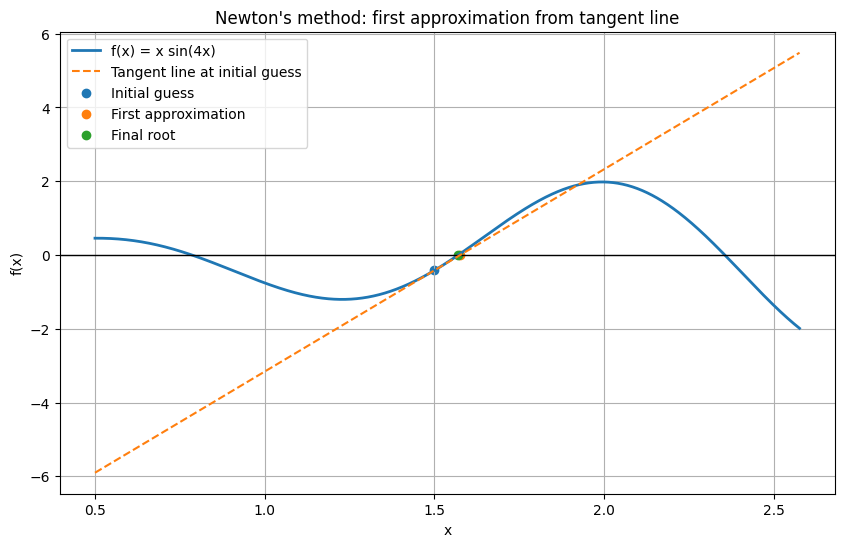

In [21]:
# Visualize Newton tangent step for one selected initial guess

selected_x0 = 1.5

root, iterations, reason, history = newton_method(selected_x0)

# First Newton approximation
x1 = history[0]["x_n"]

x_plot = np.linspace(min(selected_x0, x1) - 1, max(selected_x0, x1) + 1, 1000)
y_plot = f(x_plot)

# Tangent line at x0: y = f'(x0)(x - x0) + f(x0)
tangent_line = df(selected_x0) * (x_plot - selected_x0) + f(selected_x0)

plt.figure(figsize=(10, 6))

plt.plot(x_plot, y_plot, label="f(x) = x sin(4x)", linewidth=2)
plt.axhline(0, color="black", linewidth=1)

plt.plot(
    x_plot,
    tangent_line,
    linestyle="--",
    label="Tangent line at initial guess"
)

plt.scatter(selected_x0, f(selected_x0), label="Initial guess")
plt.scatter(x1, 0, label="First approximation")
plt.scatter(root, f(root), label="Final root")

plt.title("Newton's method: first approximation from tangent line")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

## 5. Results and Discussion

Newton’s method was applied repeatedly for a wide range of initial approximations distributed over the interval \([-2,2]\). For each starting point, the obtained root, the number of iterations, and the stopping criterion were recorded and analyzed.

The computational results demonstrate that the investigated nonlinear function possesses multiple roots. Depending on the selected initial approximation, Newton’s method converged to different solutions of the equation. The obtained roots include values near

$$
0,\ \pm0.785398,\ \pm1.570796,\ \pm3.141593,
$$

as well as several more distant roots such as

$$
\pm5.497787 \quad \text{and} \quad \pm13.351769.
$$

The graphical analysis confirms that the convergence behavior of Newton’s method depends strongly on the initial approximation. Initial guesses located in neighboring regions frequently converged to the same root, forming characteristic convergence intervals. However, small changes in the starting point occasionally redirected the iterative process toward entirely different roots of the nonlinear equation.

The obtained results additionally demonstrate the high convergence speed of Newton’s method. In most numerical experiments, convergence was achieved within two to six iterations. This behavior confirms the quadratic convergence property of the method when the initial approximation is sufficiently close to the root.

The largest number of iterations was observed for initial approximations close to zero. In these cases, the method required up to nine iterations before satisfying the stopping criterion. This slower convergence behavior is associated with the local properties of the function near the origin and with smaller correction steps during the iterative process.

A special case occurred for the initial approximation

$$
x_0=0,
$$

where the derivative became zero. Since Newton’s formula requires division by the derivative, the iterative process could not continue and the computation was terminated immediately. This example illustrates one of the important limitations of Newton’s method and demonstrates the necessity of additional numerical safeguards in practical implementations.

The dependence between the initial approximation and the obtained root was visualized graphically. The resulting plot clearly shows that Newton’s method does not necessarily converge to the nearest root. Instead, the convergence behavior is governed by the local geometry of the nonlinear function and the tangent-line approximation used during each iteration.

The analysis of iteration counts demonstrates that convergence speed varies significantly depending on the starting point. Initial approximations located closer to stable convergence regions generally required fewer iterations, while approximations near transition regions between different roots produced slower convergence.

The grouped root analysis additionally illustrates the distribution of convergence regions. Several roots attracted large numbers of initial approximations, while more distant roots were obtained only for isolated starting points. This behavior reflects the nonlinear structure of the investigated function and the sensitivity of Newton’s method to the initial approximation.

The detailed iteration histories demonstrate the rapid decrease of both the approximation error and the functional value during the convergence process. For starting points sufficiently close to stable convergence regions, the approximation improved very rapidly after only a few iterations.

The geometric visualization of Newton’s method clearly illustrates the tangent-line interpretation of the algorithm. The first Newton approximation is obtained as the intersection of the tangent line with the \(x\)-axis, after which the iterative process gradually approaches the root of the nonlinear equation.

## 6. Conclusions

In this part of the laboratory work, the convergence behavior of Newton’s method was investigated for a wide range of initial approximations. The numerical experiments were performed for the nonlinear function

$$
f(x)=x\sin(4x),
$$

which possesses multiple roots distributed over the investigated interval.

The obtained results demonstrated that Newton’s method converges very rapidly when the initial approximation is sufficiently close to a stable convergence region. In most computational experiments, the method required only a small number of iterations to satisfy the prescribed stopping criteria, confirming the high computational efficiency of the algorithm.

The analysis additionally showed that the convergence behavior of Newton’s method depends strongly on the initial approximation. Different starting points frequently converged to different roots of the nonlinear equation, even when the initial guesses were relatively close to each other. This behavior illustrates the sensitivity of Newton’s method to the local geometry of the investigated function.

The numerical experiments also demonstrated that convergence becomes slower near certain regions of the function, particularly near the origin, where the method required a larger number of iterations. A special case was observed for the initial approximation

$$
x_0=0,
$$

where the derivative became zero and the iterative process could not continue.

The graphical analysis provided a clear visualization of the dependence between the initial approximation and the obtained root, as well as the variation of convergence speed across different starting points. The tangent-line visualization additionally illustrated the geometric interpretation of Newton’s method and explained the mechanism by which successive approximations approach the solution.

Overall, the performed computational experiments demonstrated both the advantages and limitations of Newton’s method. The method provides extremely rapid convergence and high numerical efficiency, but its performance depends strongly on the choice of the initial approximation and on the local properties of the nonlinear function.